In [2]:
import os

dataroot = "out/everyday"

summary = {}

for class_name in os.listdir(dataroot):
    class_path = os.path.join(dataroot, class_name)
    if not os.path.isdir(class_path):
        continue

    objects = os.listdir(class_path)
    objects = [o for o in objects if os.path.isdir(os.path.join(class_path, o))]

    summary[class_name] = {
        "num_objects": len(objects),
        "objects": {}
    }

    for obj in objects:
        obj_path = os.path.join(class_path, obj)

        break_ways = [
            w for w in os.listdir(obj_path)
            if os.path.isdir(os.path.join(obj_path, w))
        ]

        summary[class_name]["objects"][obj] = {}

        for way in break_ways:
            way_path = os.path.join(obj_path, way)

            pieces = [
                f for f in os.listdir(way_path)
                if f.endswith(".obj")
            ]

            summary[class_name]["objects"][obj][way] = len(pieces)



In [ ]:
# Pretty print
for cls, cls_data in summary.items():
    print(f"Class: {cls} | #Objects: {cls_data['num_objects']}")
    for obj, ways in cls_data["objects"].items():
        print(f"  Object: {obj}")
        for way, n_pieces in ways.items():
            print(f"    {way}: {n_pieces} pieces")
    print()

In [7]:
import os
import csv

def export_paths_with_n_pieces(dataroot, target_pieces, out_csv):
    """
    Scan dataset and save paths of 'break ways' that contain exactly target_pieces .obj files.

    Args:
        dataroot (str): root directory
        target_pieces (int): number of pieces to filter
        out_csv (str): output CSV file path
    """

    rows = []

    for class_name in os.listdir(dataroot):
        class_path = os.path.join(dataroot, class_name)
        if not os.path.isdir(class_path):
            continue

        for obj in os.listdir(class_path):
            obj_path = os.path.join(class_path, obj)
            if not os.path.isdir(obj_path):
                continue

            for way in os.listdir(obj_path):
                way_path = os.path.join(obj_path, way)
                if not os.path.isdir(way_path):
                    continue

                pieces = [
                    f for f in os.listdir(way_path)
                    if f.endswith(".obj")
                ]

                if len(pieces) == target_pieces:
                    for piece in pieces:
                        rows.append([
                            class_name,
                            obj,
                            way,
                            len(pieces),
                            os.path.join(way_path, piece)
                        ])

    # write CSV
    with open(out_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["class", "object", "way", "num_pieces", "path"])
        writer.writerows(rows)

    print(f"Saved {len(rows)} entries to {out_csv}")

In [9]:
export_paths_with_n_pieces(
    dataroot="out/everyday",
    target_pieces=1,
    out_csv="ways_with_1_pieces.csv"
)

Saved 498 entries to ways_with_1_pieces.csv


In [8]:
export_paths_with_n_pieces(
    dataroot="out/everyday",
    target_pieces=2,
    out_csv="ways_with_2_pieces.csv"
)

Saved 41662 entries to ways_with_2_pieces.csv


In [3]:
import plotly.graph_objects as go
import numpy as np


def load_obj(path):
    """
    Minimal OBJ loader (supports v + f only, triangular or quad faces).
    """
    vertices = []
    faces = []

    with open(path, 'r') as f:
        for line in f:
            if line.startswith('v '):
                vertices.append(list(map(float, line.strip().split()[1:4])))

            elif line.startswith('f '):
                face = []
                for v in line.strip().split()[1:]:
                    idx = v.split('/')[0]  # handle v/vt/vn
                    face.append(int(idx) - 1)
                
                # triangulate if quad
                if len(face) == 3:
                    faces.append(face)
                elif len(face) == 4:
                    faces.append([face[0], face[1], face[2]])
                    faces.append([face[0], face[2], face[3]])

    return np.array(vertices), np.array(faces)


def show_two_obj_plotly(path1, path2, shift=False):
    v1, f1 = load_obj(path1)
    v2, f2 = load_obj(path2)

    if shift:
        # shift second mesh along x-axis
        shift_val = (v1[:, 0].max() - v1[:, 0].min()) * 1.5
        v2 = v2 + np.array([shift_val, 0, 0])

    fig = go.Figure()

    # mesh 1
    fig.add_trace(go.Mesh3d(
        x=v1[:, 0], y=v1[:, 1], z=v1[:, 2],
        i=f1[:, 0], j=f1[:, 1], k=f1[:, 2],
        opacity=0.6,
        name="mesh1"
    ))

    # mesh 2
    fig.add_trace(go.Mesh3d(
        x=v2[:, 0], y=v2[:, 1], z=v2[:, 2],
        i=f2[:, 0], j=f2[:, 1], k=f2[:, 2],
        opacity=0.6,
        name="mesh2"
    ))

    fig.update_layout(
        scene=dict(aspectmode='data'),
        title="OBJ Mesh Visualization"
    )

    fig.show()

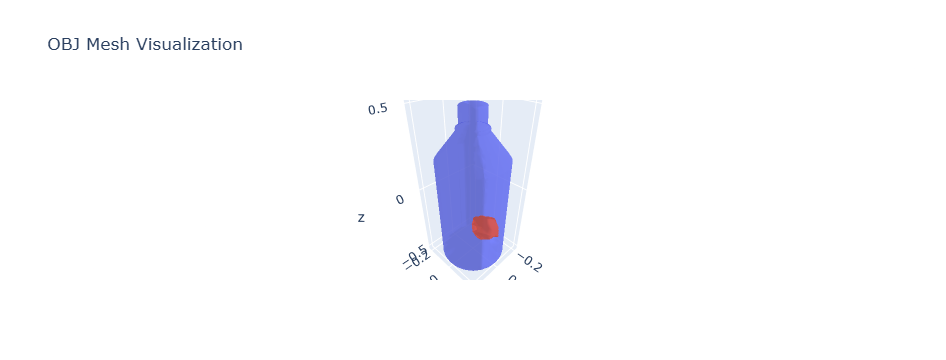

In [13]:
mesha ="out/everyday/Bottle/d7305324e9dd49eccee5e41d780064a2/fractured_37/piece_0.obj"
meshb ="out/everyday/Bottle/d7305324e9dd49eccee5e41d780064a2/fractured_37/piece_1.obj"


show_two_obj_plotly(mesha, meshb)

In [10]:
import os
import pandas as pd
import trimesh


def get_base_mesh_path(piece_path):
    parts = piece_path.split(os.sep)
    parts[-2] = "mode_0"
    parts[-1] = "piece_0.obj"
    return os.sep.join(parts)


def safe_load_area(path):
    """
    Load mesh and compute surface area safely.
    """
    try:
        mesh = trimesh.load(path, force='mesh')

        if mesh.is_empty:
            return None

        return mesh.area

    except Exception:
        return None


def filter_by_surface_ratio(input_csv, output_csv, threshold=0.5):
    """
    Keep rows where piece_area / base_area >= threshold
    """

    df = pd.read_csv(input_csv)
    results = []

    for _, row in df.iterrows():
        piece_path = row["path"]
        base_path = get_base_mesh_path(piece_path)

        if not os.path.exists(base_path):
            continue

        a_piece = safe_load_area(piece_path)
        a_base = safe_load_area(base_path)

        if a_piece is None or a_base is None or a_base == 0:
            continue

        ratio = a_piece / a_base

        if ratio >= threshold:
            row_out = row.copy()
            row_out["base_path"] = base_path
            row_out["surface_ratio"] = ratio
            results.append(row_out)

    out_df = pd.DataFrame(results)
    out_df.to_csv(output_csv, index=False)

    print(f"Saved {len(out_df)} filtered rows to {output_csv}")

In [8]:
get_base_mesh_path("out/everyday/WineBottle/a34966853ab2272ab2047d3072d5e051/fractured_1/piece_1.obj")

'out/everyday/WineBottle/a34966853ab2272ab2047d3072d5e051/mode_0/piece_0.obj'

In [11]:
filter_by_surface_ratio("ways_with_2_pieces.csv", "filtered_test.csv", threshold=0.5)

Saved 20943 filtered rows to filtered_test.csv


In [29]:
import os
import numpy as np
import pandas as pd
import trimesh


def get_other_piece_path(piece_path):
    """
    piece_0.obj <-> piece_1.obj
    """
    if "piece_0.obj" in piece_path:
        return piece_path.replace("piece_0.obj", "piece_1.obj")
    elif "piece_1.obj" in piece_path:
        return piece_path.replace("piece_1.obj", "piece_0.obj")
    else:
        return None


def compute_face_centroids(mesh):
    """
    Compute centroids manually to guarantee alignment with mesh.faces
    """
    v = mesh.vertices
    f = mesh.faces
    return (v[f[:, 0]] + v[f[:, 1]] + v[f[:, 2]]) / 3.0


def label_overlap_faces(mesh_a, mesh_b, threshold=1e-4):
    """
    Label faces in mesh_a that overlap with mesh_b.
    GUARANTEED to align with original OBJ face indices.
    """

    centroids = compute_face_centroids(mesh_a)

    # try trimesh proximity (fast, needs rtree)
    try:
        _, distance, _ = trimesh.proximity.closest_point(mesh_b, centroids)

    except Exception:
        # fallback: KD-tree (no rtree)
        from scipy.spatial import cKDTree
        tree = cKDTree(mesh_b.vertices)
        distance, _ = tree.query(centroids)

    labels = (distance < threshold).astype(np.int32)

    # 🔒 safety check
    assert len(labels) == len(mesh_a.faces)

    return labels


def save_labels_with_index(out_path, labels):
    """
    Save as: face_index,label
    """
    with open(out_path, "w") as f:
        for i, l in enumerate(labels):
            f.write(f"{l}\n")


def process_csv_and_label(input_csv, threshold=1e-4):
    df = pd.read_csv(input_csv)

    for _, row in df.iterrows():
        piece_path = row["path"]
        other_path = get_other_piece_path(piece_path)

        if other_path is None or not os.path.exists(other_path):
            continue

        out_path = piece_path.replace(".obj", "_labels.txt")

        try:
            # ✅ CRITICAL: preserve face order
            mesh_a = trimesh.load(piece_path, process=False, maintain_order=True)
            mesh_b = trimesh.load(other_path, process=False, maintain_order=True)

            if mesh_a.is_empty or mesh_b.is_empty:
                continue

            labels = label_overlap_faces(mesh_a, mesh_b, threshold)

            save_labels_with_index(out_path, labels)

            print(f"Done {out_path}")

        except Exception as e:
            print(f"Skip {piece_path}: {e}")

In [30]:
%load_ext autotime
process_csv_and_label("test.csv")

Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_11/piece_0_labels.txt
Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_17/piece_0_labels.txt
Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_18/piece_0_labels.txt
Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_5/piece_0_labels.txt
Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_23/piece_0_labels.txt
Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_54/piece_0_labels.txt
Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_15/piece_0_labels.txt
Done out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_46/piece_0_labels.txt
time: 10.8 s (started: 2026-04-23 17:32:03 +07:00)


In [37]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go

def visualize_from_csv(csv_path, index=0):
    df = pd.read_csv(csv_path)

    row = df.iloc[index]
    obj_path = row["path"]

    # label file assumed: piece_x_labels.txt
    label_path = obj_path.replace(".obj", "_labels.txt")
    if not os.path.exists(label_path):
        print("Label file not found:", label_path)
        return

    # load mesh
    mesh = trimesh.load(obj_path, process=False, maintain_order=True)
    v = mesh.vertices
    f = mesh.faces
    # load labels
    labels = np.loadtxt(label_path)

    if len(labels) != len(f):
        print("Mismatch faces vs labels")
        return

    # assign color per face
    face_colors = np.where(labels == 1, 1.0, 0.0)

    fig = go.Figure()

    fig.add_trace(go.Mesh3d(
        x=v[:, 0],
        y=v[:, 1],
        z=v[:, 2],
        i=f[:, 0],
        j=f[:, 1],
        k=f[:, 2],
        intensity=face_colors,   # color by label,
        intensitymode="cell",
        colorscale=[
            [0, "blue"],   # non-overlap
            [1, "red"]     # overlap
        ],
        showscale=True,
        opacity=1.0
    ))

    fig.update_layout(
        title=f"Labeled Mesh: {obj_path}",
        scene=dict(aspectmode='data')
    )

    fig.show()

time: 623 μs (started: 2026-04-23 17:49:47 +07:00)


In [41]:
 visualize_from_csv(
    csv_path="filtered_test.csv",
    index=100
)

time: 54.2 ms (started: 2026-04-23 18:27:54 +07:00)


In [1]:
from pathlib import Path
%load_ext autotime

def remove_all_png(directory, dry_run=False):
    """
    Remove ALL .png files recursively from directory.

    Args:
        directory (str or Path)
        dry_run (bool): if True, only print what would be deleted
    """
    directory = Path(directory)

    if not directory.exists():
        print(f"Directory not found: {directory}")
        return

    count = 0

    for png_file in directory.rglob("*.pt"):
        try:
            if dry_run:
                print(f"[DELETE] {png_file}")
            else:
                png_file.unlink()
            count += 1
        except Exception as e:
            print(f"Failed: {png_file} | {e}")

    print(f"{'Would delete' if dry_run else 'Deleted'} {count} pt files")

time: 486 μs (started: 2026-04-29 00:17:08 +07:00)


In [3]:
dataroot = "out/everyday"
remove_all_png(dataroot,False)

Deleted 3558 pt files
time: 1.56 s (started: 2026-04-29 00:18:29 +07:00)


In [1]:
import os
import pandas as pd


def get_image_paths_from_csv(csv_path, index=0, mode="frac"):
    """
    Build image paths from CSV 'path' column.

    Args:
        csv_path: CSV file
        index: row index
        mode: "frac" or "base"

    Returns:
        dict with overview + list of piece images
    """

    df = pd.read_csv(csv_path)
    obj_path = df.iloc[index]["path"]

    folder = os.path.dirname(obj_path)
    base_name = os.path.basename(obj_path).replace(".obj", "")

    # overview image
    overview = os.path.join(folder, f"{base_name}_{mode}_view_overview.png")

    # piece images (frac00 → frac04)
    pieces = []
    for i in range(5):
        pieces.append(
            os.path.join(folder, f"{base_name}_{mode}_view_frac{i:02d}.png")
        )

    return {
        "overview": overview,
        "pieces": pieces
    }

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def plot_overview_and_pieces(image_dict):
    """
    Plot 1 overview + 5 piece images (total 6 subplots)
    """

    overview = image_dict["overview"]
    pieces = image_dict["pieces"]

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    # flatten for easy indexing
    axes = axes.flatten()

    # --- Overview ---
    if os.path.exists(overview):
        img = mpimg.imread(overview)
        axes[0].imshow(img)
        axes[0].set_title("Overview")
    else:
        axes[0].set_title("Overview (missing)")
    axes[0].axis("off")

    # --- Pieces ---
    for i in range(5):
        ax = axes[i + 1]

        if os.path.exists(pieces[i]):
            img = mpimg.imread(pieces[i])
            ax.imshow(img)
            ax.set_title(f"Piece {i}")
        else:
            ax.set_title(f"Piece {i} (missing)")

        ax.axis("off")

    plt.tight_layout()
    plt.show()

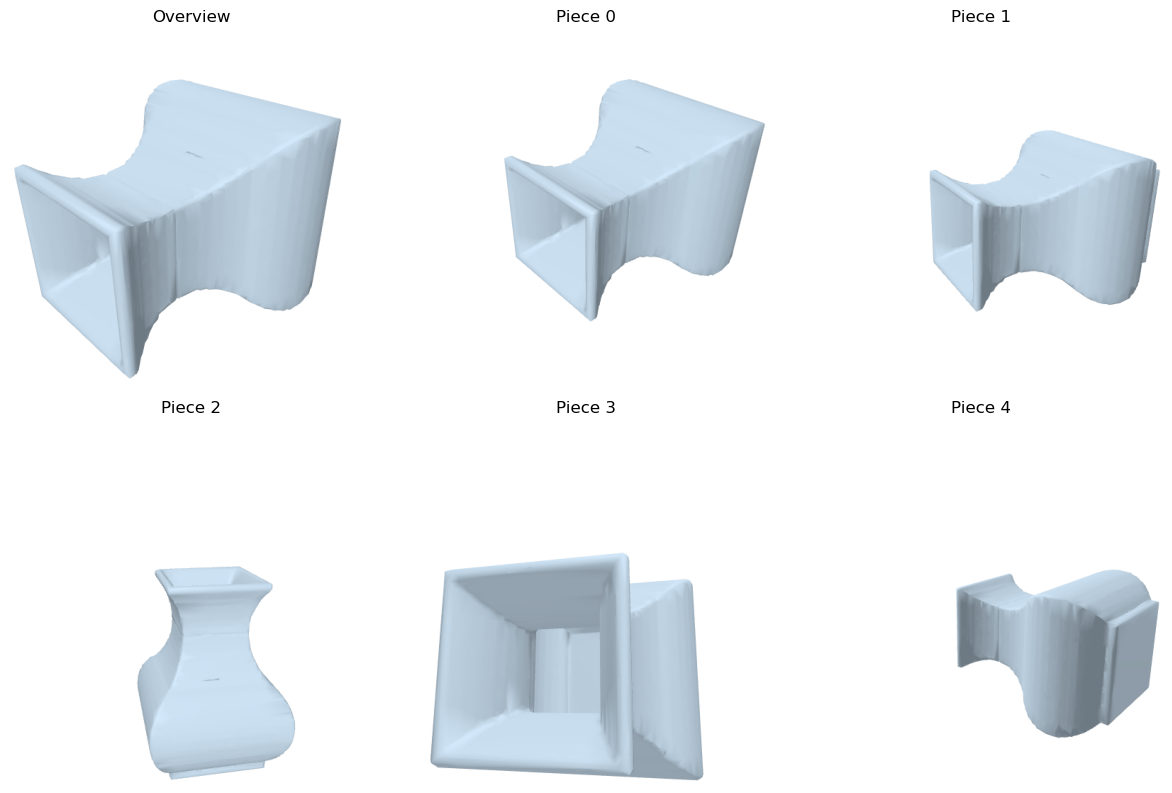

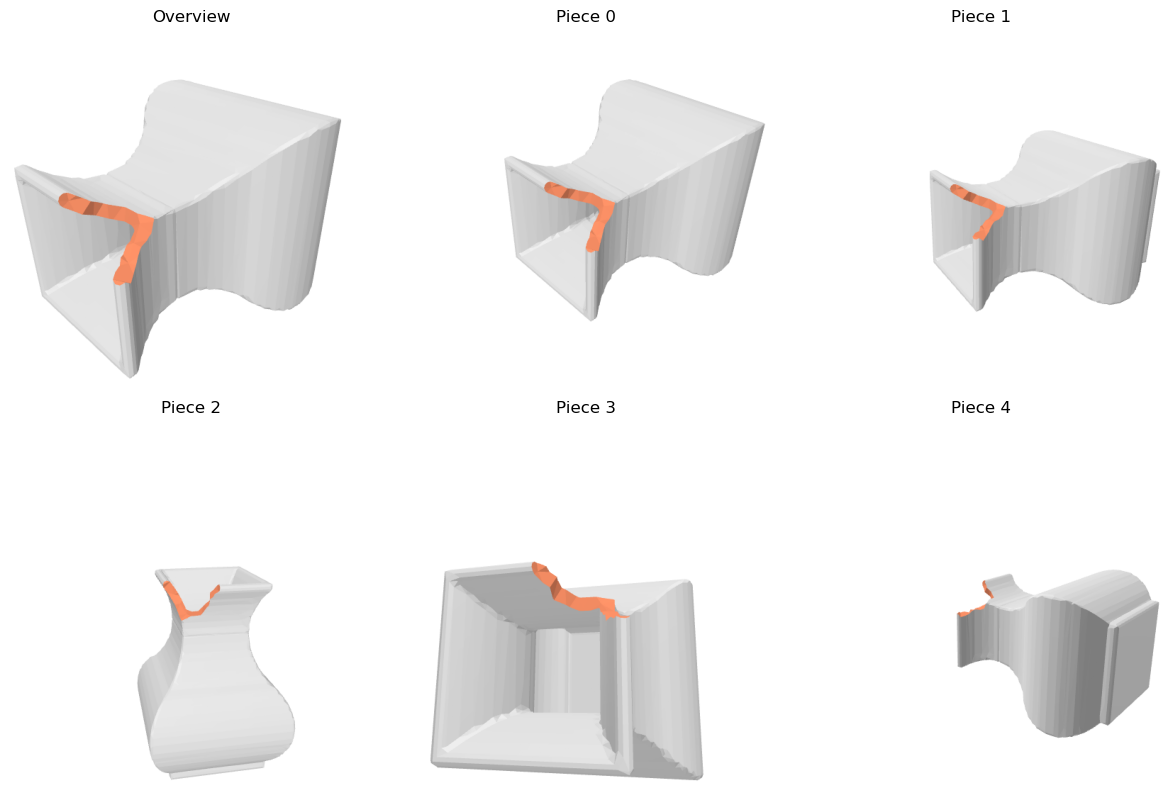

In [6]:
test_idx = 1002

img_dict = get_image_paths_from_csv(
    csv_path="filtered_test.csv",
    index=test_idx,
    mode="base"   # or "base"
)

plot_overview_and_pieces(img_dict)

img_dict = get_image_paths_from_csv(
    csv_path="filtered_test.csv",
    index=test_idx,
    mode="frac"   # or "base"
)

plot_overview_and_pieces(img_dict)

In [13]:
img_dict

{'overview': 'out/everyday/Vase/bd0274fe8ca44aa035836c728d324152/fractured_13/piece_0_frac_view_overview.png',
 'pieces': ['out/everyday/Vase/bd0274fe8ca44aa035836c728d324152/fractured_13/piece_0_frac_view_frac00.png',
  'out/everyday/Vase/bd0274fe8ca44aa035836c728d324152/fractured_13/piece_0_frac_view_frac01.png',
  'out/everyday/Vase/bd0274fe8ca44aa035836c728d324152/fractured_13/piece_0_frac_view_frac02.png',
  'out/everyday/Vase/bd0274fe8ca44aa035836c728d324152/fractured_13/piece_0_frac_view_frac03.png',
  'out/everyday/Vase/bd0274fe8ca44aa035836c728d324152/fractured_13/piece_0_frac_view_frac04.png']}

In [15]:
import os
import pandas as pd


def get_paired_image_paths(csv_path, index=0, num_pieces=5):
    """
    Return paired image paths for frac/base.

    Output format:
    {
        "overview": {"frac": ..., "base": ...},
        "pieces": [
            {"frac": ..., "base": ...},  # piece 0
            ...
        ]
    }
    """

    df = pd.read_csv(csv_path)
    obj_path = df.iloc[index]["path"]

    folder = os.path.dirname(obj_path)
    base_name = os.path.basename(obj_path).replace(".obj", "")

    data = {
        "overview": {
            "frac": os.path.join(folder, f"{base_name}_frac_view_overview.png"),
            "base": os.path.join(folder, f"{base_name}_base_view_overview.png"),
        },
        "pieces": []
    }

    for i in range(num_pieces):
        data["pieces"].append({
            "frac": os.path.join(folder, f"{base_name}_frac_view_frac{i:02d}.png"),
            "base": os.path.join(folder, f"{base_name}_base_view_frac{i:02d}.png"),
        })

    return data

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def plot_paired_images(data):
    """
    Plot:
    Row 1: Overview (frac | base)
    Row 2+: Pieces (frac | base)
    """

    num_pieces = len(data["pieces"])

    fig, axes = plt.subplots(num_pieces + 1, 2, figsize=(8, 3 * (num_pieces + 1)))

    # --- Overview ---
    for col, mode in enumerate(["frac", "base"]):
        path = data["overview"][mode]
        ax = axes[0, col]

        if os.path.exists(path):
            ax.imshow(mpimg.imread(path))
            ax.set_title(f"Overview ({mode})")
        else:
            ax.set_title(f"Overview ({mode}) - missing")

        ax.axis("off")

    # --- Pieces ---
    for i, piece in enumerate(data["pieces"]):
        for col, mode in enumerate(["frac", "base"]):
            path = piece[mode]
            ax = axes[i + 1, col]

            if os.path.exists(path):
                ax.imshow(mpimg.imread(path))
                ax.set_title(f"Piece {i} ({mode})")
            else:
                ax.set_title(f"Piece {i} ({mode}) - missing")

            ax.axis("off")

    plt.tight_layout()
    plt.show()

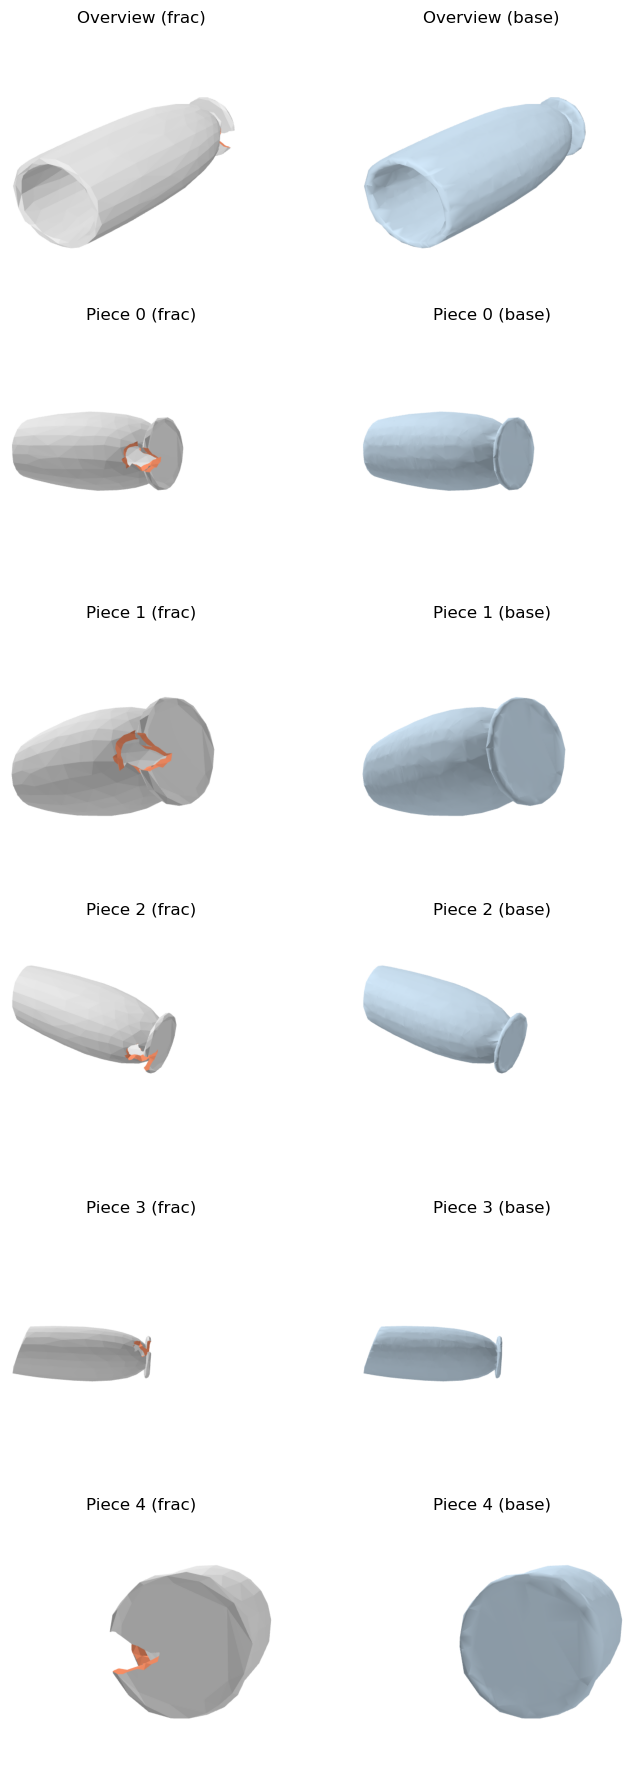

In [17]:
data = get_paired_image_paths(
    csv_path="filtered_test.csv",
    index=3000,
    num_pieces=5
)

plot_paired_images(data)

In [22]:
import os
from PIL import Image
import pandas as pd


def save_pair_same_dir(csv_path, index=0, num_pieces=5):
    df = pd.read_csv(csv_path)
    obj_path = df.iloc[index]["path"]

    folder = os.path.dirname(obj_path)
    base_name = os.path.basename(obj_path).replace(".obj", "")

    def combine_and_save(base_path, frac_path, out_path):
        if not os.path.exists(base_path) or not os.path.exists(frac_path):
            print(f"Missing: {base_path} or {frac_path}")
            return

        img_base = Image.open(base_path).convert("RGB")
        img_frac = Image.open(frac_path).convert("RGB")

        # match height
        h = min(img_base.height, img_frac.height)
        img_base = img_base.resize((int(img_base.width * h / img_base.height), h))
        img_frac = img_frac.resize((int(img_frac.width * h / img_frac.height), h))

        # base LEFT, frac RIGHT
        new_img = Image.new("RGB", (img_base.width + img_frac.width, h))
        new_img.paste(img_base, (0, 0))
        new_img.paste(img_frac, (img_base.width, 0))

        new_img.save(out_path)
        print(f"Saved: {out_path}")

    # --- overview ---
    base_overview = os.path.join(folder, f"{base_name}_base_view_overview.png")
    frac_overview = os.path.join(folder, f"{base_name}_frac_view_overview.png")

    combine_and_save(
        base_overview,
        frac_overview,
        os.path.join(folder, f"{base_name}_overview_pair.png")
    )

    # --- pieces ---
    for i in range(num_pieces):
        base_img = os.path.join(folder, f"{base_name}_base_view_frac{i:02d}.png")
        frac_img = os.path.join(folder, f"{base_name}_frac_view_frac{i:02d}.png")

        out_path = os.path.join(folder, f"{base_name}_pair{i:02d}.png")

        combine_and_save(base_img, frac_img, out_path)

In [23]:
save_pair_same_dir(
    csv_path="filtered_test.csv",
    index=0,
    num_pieces=5
)

Saved: out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_11/piece_0_overview_pair.png
Saved: out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_11/piece_0_pair00.png
Saved: out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_11/piece_0_pair01.png
Saved: out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_11/piece_0_pair02.png
Saved: out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_11/piece_0_pair03.png
Saved: out/everyday/Plate/1389e932a2c776d83c143af07c12991a/fractured_11/piece_0_pair04.png


In [2]:
import os
from PIL import Image
import pandas as pd


def combine_and_save(base_path, frac_path, out_path, skip_if_exists=True):
    if skip_if_exists and os.path.exists(out_path):
        # print(f"Skiping: {base_path} or {frac_path}")
        return

    if not os.path.exists(base_path) or not os.path.exists(frac_path):
        print(f"Missing: {base_path} or {frac_path}")
        return

    try:
        img_base = Image.open(base_path).convert("RGB")
        img_frac = Image.open(frac_path).convert("RGB")

        # match height
        h = min(img_base.height, img_frac.height)
        img_base = img_base.resize((int(img_base.width * h / img_base.height), h))
        img_frac = img_frac.resize((int(img_frac.width * h / img_frac.height), h))

        # base LEFT, frac RIGHT
        new_img = Image.new("RGB", (img_base.width + img_frac.width, h))
        new_img.paste(img_base, (0, 0))
        new_img.paste(img_frac, (img_base.width, 0))

        new_img.save(out_path)

    except Exception as e:
        print(f"Error: {out_path} | {e}")


def batch_save_pairs_fixed5(csv_path, skip_if_exists=True):
    df = pd.read_csv(csv_path)

    total = 0
    total_obj = 0
    n = len(df)
    for _, row in df.iterrows():
        total_obj += 1
        print(f"Processed ~{total_obj}/{n}")
        obj_path = row["path"]

        folder = os.path.dirname(obj_path)
        base_name = os.path.basename(obj_path).replace(".obj", "")

        # --- overview ---
        base_overview = os.path.join(folder, f"{base_name}_base_view_overview.png")
        frac_overview = os.path.join(folder, f"{base_name}_frac_view_overview.png")

        out_overview = os.path.join(folder, f"{base_name}_overview_pair.png")

        combine_and_save(base_overview, frac_overview, out_overview, skip_if_exists)
        total += 1

        # --- fixed 5 pieces ---
        for i in range(5):
            base_img = os.path.join(folder, f"{base_name}_base_view_frac{i:02d}.png")
            frac_img = os.path.join(folder, f"{base_name}_frac_view_frac{i:02d}.png")

            out_path = os.path.join(folder, f"{base_name}_pair{i:02d}.png")

            combine_and_save(base_img, frac_img, out_path, skip_if_exists)
            total += 1

    print(f"Done. Processed ~{total} image pairs")

In [3]:
batch_save_pairs_fixed5("filtered_test.csv")

Processed ~1/20943
Processed ~2/20943
Processed ~3/20943
Processed ~4/20943
Processed ~5/20943
Processed ~6/20943
Processed ~7/20943
Processed ~8/20943
Processed ~9/20943
Processed ~10/20943
Processed ~11/20943
Processed ~12/20943
Processed ~13/20943
Processed ~14/20943
Processed ~15/20943
Processed ~16/20943
Processed ~17/20943
Processed ~18/20943
Processed ~19/20943
Processed ~20/20943
Processed ~21/20943
Processed ~22/20943
Processed ~23/20943
Processed ~24/20943
Processed ~25/20943
Processed ~26/20943
Processed ~27/20943
Processed ~28/20943
Processed ~29/20943
Processed ~30/20943
Processed ~31/20943
Processed ~32/20943
Processed ~33/20943
Processed ~34/20943
Processed ~35/20943
Processed ~36/20943
Processed ~37/20943
Processed ~38/20943
Processed ~39/20943
Processed ~40/20943
Processed ~41/20943
Processed ~42/20943
Processed ~43/20943
Processed ~44/20943
Processed ~45/20943
Processed ~46/20943
Processed ~47/20943
Processed ~48/20943
Processed ~49/20943
Processed ~50/20943
Processed

In [3]:
import os
import pandas as pd


def build_pair_list_csv(input_csv, output_csv):
    """
    Output CSV columns:
    - path
    - class
    - overview_pair
    - piece_pairs (list of 5 image paths)
    """

    df = pd.read_csv(input_csv)
    rows = []

    for _, row in df.iterrows():
        obj_path = row["path"]

        cls = row["class"]

        folder = os.path.dirname(obj_path)
        base_name = os.path.basename(obj_path).replace(".obj", "")

        overview_pair = os.path.join(folder, f"{base_name}_overview_pair.png")

        # build 5 piece pair paths
        piece_pairs = [
            os.path.join(folder, f"{base_name}_pair{i:02d}.png")
            for i in range(5)
        ]
        piece_pairs.append(overview_pair)
        # optional: check existence
        if not os.path.exists(overview_pair):
            continue
        if not all(os.path.exists(p) for p in piece_pairs):
            continue

        rows.append({
            "path": obj_path,
            "class": cls,
            "pair_images_path": piece_pairs  # stored as list
        })

    out_df = pd.DataFrame(rows)
    out_df.to_csv(output_csv, index=False)

    print(f"Saved {len(out_df)} rows to {output_csv}")

In [4]:
build_pair_list_csv(
    input_csv="test.csv",
    output_csv="paired_dataset_test.csv"
)

Saved 8 rows to paired_dataset_test.csv


In [5]:
build_pair_list_csv(
    input_csv="filtered_test.csv",
    output_csv="paired_dataset.csv"
)

Saved 20943 rows to paired_dataset.csv


In [1]:
import pandas as pd


def subset_n_per_class(input_csv, output_csv, n_per_class, random_seed=42, replace=False):
    """
    Create a balanced subset with N samples per class.

    Args:
        input_csv: input file
        output_csv: output file
        n_per_class: number of samples per class
        random_seed: reproducibility
        replace: if True, oversample when class < N
    """

    df = pd.read_csv(input_csv)

    grouped = df.groupby("class")

    subsets = []

    for cls, group in grouped:
        if len(group) >= n_per_class:
            sampled = group.sample(n=n_per_class, random_state=random_seed)
        else:
            if replace:
                # oversample
                sampled = group.sample(n=n_per_class, replace=True, random_state=random_seed)
            else:
                # keep all (will be < N)
                sampled = group

        subsets.append(sampled)

    result = pd.concat(subsets).reset_index(drop=True)
    result.to_csv(output_csv, index=False)

    print(f"Saved {len(result)} rows to {output_csv}")
    print(result["class"].value_counts())

In [2]:
subset_n_per_class(
    "captions_dataset_shorttest.csv",
    "test_set.csv",
    n_per_class=20,
    replace=False
)

Saved 220 rows to test_set.csv
class
Bowl               20
Cup                20
DrinkBottle        20
DrinkingUtensil    20
PillBottle         20
Plate              20
Teacup             20
Teapot             20
ToyFigure          20
Vase               20
WineBottle         20
Name: count, dtype: int64
